In [1]:
import pandas as pd
import plotnine as p9
import numpy as np
import scanpy as sc

In [2]:
p9.options.dpi=300
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype']='none'

In [3]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()

/gstore/home/wub31/.conda/envs/py38_Scanpy_expanded/lib/python3.8/site-packages/numba/core/cpu.py:97: UserWarning: Numba extension module 'sparse._numba_extension' failed to load due to 'ModuleNotFoundError(No module named 'numba.targets')'.
/gstore/home/wub31/.conda/envs/py38_Scanpy_expanded/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
2024-08-30 13:15:06.068248: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-08-30 13:15:12.662041: W tensorflow/tsl/platform/default/dso_loader.cc:66] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared ob

scanpy==1.9.1 anndata==0.7.8 umap==0.5.3 numpy==1.23.5 scipy==1.9.3 pandas==1.5.2 scikit-learn==1.1.3 statsmodels==0.13.5 python-igraph==0.10.2 pynndescent==0.5.8


In [5]:
adata_OAK150k_ali1=sc.read_h5ad(data_dir+'/barnyard_OAK150kali1/adata_raw.h5ad')

In [6]:
K562_OAK150k_ali1=adata_OAK150k_ali1[adata_OAK150k_ali1.obs.call.isin(['GRCh38']),adata_OAK150k_ali1.var.species.isin(['GRCh38'])]

In [7]:
K562_OAK150k_ali1.var['mt'] = K562_OAK150k_ali1.var_names.str.startswith('GRCh38_MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(K562_OAK150k_ali1, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

Trying to set attribute `.var` of view, copying.


In [8]:
K562_OAK150k_ali1.obs['experiment']='OAK'

In [9]:
adata_10x_control=sc.read_h5ad(data_dir+'/barnyard_10x/adata_raw.h5ad')

In [10]:
K562_10x_control=adata_10x_control[adata_10x_control.obs.call.isin(['GRCh38']),adata_10x_control.var.species.isin(['GRCh38'])]

In [11]:
K562_10x_control.var['mt'] = K562_10x_control.var_names.str.startswith('GRCh38_MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(K562_10x_control, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

Trying to set attribute `.var` of view, copying.


In [12]:
K562_10x_control.obs['experiment']='Chromium'

In [13]:
df_compare=pd.concat([K562_10x_control.obs,K562_OAK150k_ali1.obs],ignore_index=True)

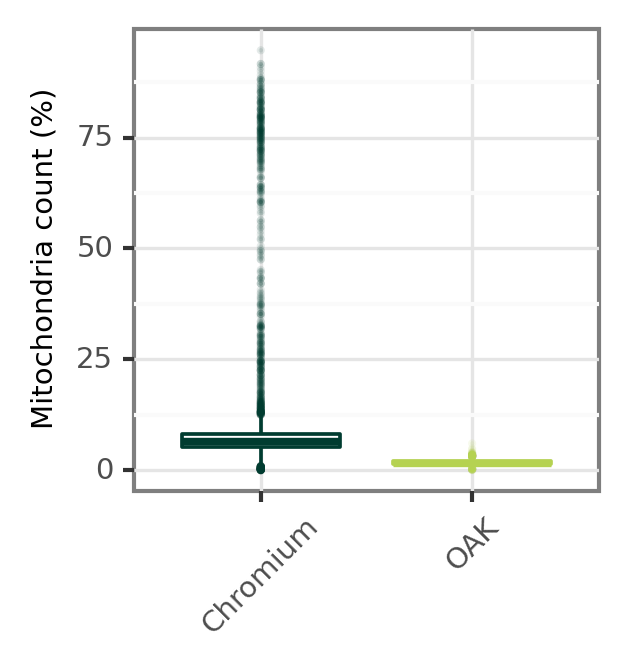

<ggplot: (2932214217960)>

In [14]:
plot=p9.ggplot(data=df_compare,
               mapping=p9.aes(x='experiment',y='pct_counts_mt',color='experiment')
              )
plot+ p9.geom_boxplot(outlier_alpha=0.1,outlier_size=0.1, show_legend=False) \
+ p9.themes.theme_bw() \
+ p9.theme(figure_size=(2, 2),axis_text_x=p9.element_text(rotation = 45)) \
+ p9.theme(text=p9.element_text(size=7)) \
+ p9.xlab('') \
+ p9.ylab('Mitochondria count (%)') \
+ p9.scale_color_manual(values = {'Chromium':'#003C30','OAK':'#B5D251'}) 


In [15]:
df_compare

,cell_bc,Read_count,barcode,GRCh38,mm10,call,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,experiment
0,AAACCCAAGGAAACGA,1335,AAACCCAAGGAAACGA-1,673,23,GRCh38,175,673.0,490.0,72.808319,Chromium
1,AAACCCAAGGGCAAGG,22972,AAACCCAAGGGCAAGG-1,15630,52,GRCh38,5031,15630.0,1466.0,9.379398,Chromium
2,AAACCCAAGTGCGCTC,10093,AAACCCAAGTGCGCTC-1,7677,28,GRCh38,3218,7677.0,538.0,7.007946,Chromium
3,AAACCCACAATCGCGC,28511,AAACCCACAATCGCGC-1,22007,65,GRCh38,5848,22007.0,1182.0,5.371018,Chromium
4,AAACCCACACGATTCA,48612,AAACCCACACGATTCA-1,37606,118,GRCh38,7417,37606.0,2302.0,6.121364,Chromium
...,...,...,...,...,...,...,...,...,...,...,...
9664,TTTGTTGCATTGCCGG,11514,TTTGTTGCATTGCCGG-1,4242,117,GRCh38,2332,4242.0,60.0,1.414427,OAK
9665,TTTGTTGGTAATCAAG,13074,TTTGTTGGTAATCAAG-1,5297,38,GRCh38,2756,5297.0,44.0,0.830659,OAK
9666,TTTGTTGGTGACTGAG,11888,TTTGTTGGTGACTGAG-1,4856,49,GRCh38,2530,4856.0,95.0,1.956343,OAK
9667,TTTGTTGGTGTGTTTG,9328,TTTGTTGGTGTGTTTG-1,3632,82,GRCh38,2342,3632.0,85.0,2.340308,OAK


In [16]:
df_compare[['barcode','pct_counts_mt','experiment']].to_csv(data_dir+'/SupFig1f.csv',header=True,index=False)

In [20]:
plot=p9.ggplot(data=df_compare,
               mapping=p9.aes(x='experiment',y='pct_counts_mt',color='experiment')
              )
pl=plot+ p9.geom_boxplot(outlier_alpha=0.1,outlier_size=0.1, show_legend=False) \
+ p9.themes.theme_bw() \
+ p9.theme(figure_size=(2, 2),axis_text_x=p9.element_text(rotation = 45)) \
+ p9.theme(text=p9.element_text(size=7)) \
+ p9.xlab('') \
+ p9.ylab('Mitochondria count (%)') \
+ p9.ylim(0,25) \
+ p9.scale_color_manual(values = {'Chromium':'#003C30','OAK':'#B5D251'}) 
fig=pl.draw()
fig.set_size_inches(2, 2)
fig.savefig('MT_pct.svg',format='svg',dpi=300,bbox_inches='tight')  

/gstore/home/wub31/.conda/envs/py38_Scanpy_expanded/lib/python3.8/site-packages/plotnine/layer.py:333: PlotnineWarning: stat_boxplot : Removed 294 rows containing non-finite values.
